# Simple Linear Regression

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [121]:
# Read the dataset-:
df = pd.read_csv("height-weight.csv")

In [122]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


Text(0, 0.5, 'Height')

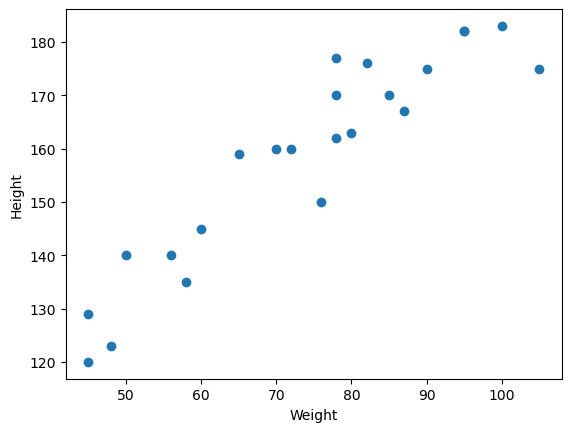

In [123]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [124]:
# divide our dataset into independent and dependent features-:
X=df[['Weight']] #independent features
y=df[['Height'] ]  #dependent features

In [125]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [126]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [127]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [128]:
X.shape

(23, 1)

In [129]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18, 1), (5, 1))

In [130]:
# Standardize the dataset Train independent data only-:
# Linear Regression needs STANDARDIZATION-:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

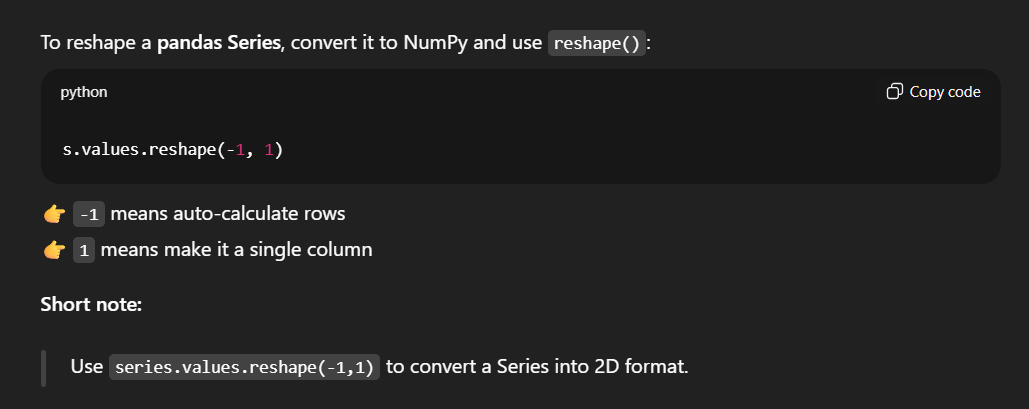

In [131]:
X_train

,Weight
12,105
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76


In [132]:
# fit method will learn mean and std-dev of X_train and then transform method will apply Z-score on each data-point of X_train and then the entire dataset is STANDARDIZED with mean=0 and std-dev=1
X_train = scaler.fit_transform(X_train)

In [133]:
X_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [134]:
# Here X_test is STANDARDIZED via transform method using mean and std-dev of X_train-:
X_test = scaler.transform(X_test)

In [135]:
X_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

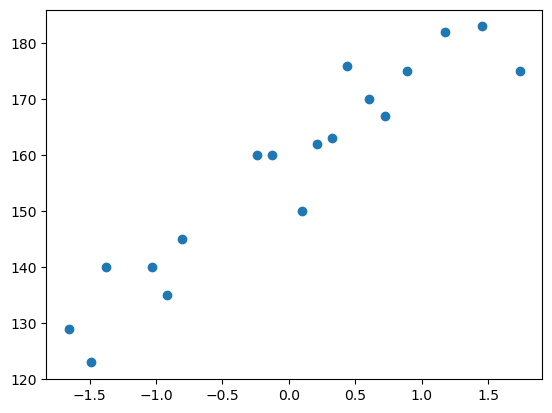

In [136]:
plt.scatter(X_train,y_train)

In [137]:
# Train the Simple Linear Regression Model-:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [138]:
regressor.fit(X_train,y_train)

LinearRegression()

In [139]:
print(f"Slope or Coefficient of weight is: {regressor.coef_}")

Slope or Coefficient of weight is: [[17.03440872]]


In [140]:
regressor.intercept_

array([157.5])

In [141]:
# B.F.L equation => y = 17.03440872*x1 + 157.5

In [142]:
type(X_train)

numpy.ndarray

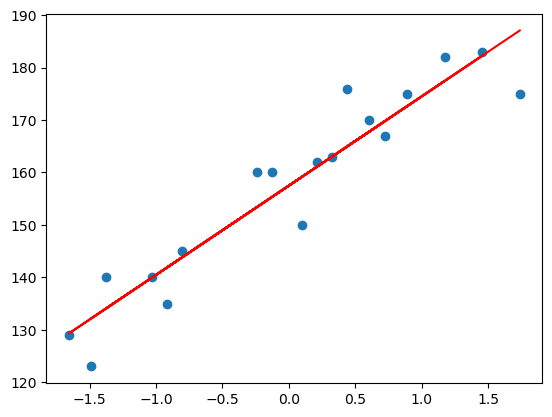

In [143]:
plt.scatter(X_train,y_train)
# plt.plot(X_train,regressor.predict(X_train))
plt.plot(X_train,157.5+17.03440872*X_train,color="r")

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =157.5 + 17.03(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

In [144]:
y_pred_test = regressor.predict(X_test)

In [145]:
y_pred_test

array([[161.08467086],
       [161.08467086],
       [129.3041561 ],
       [177.45645118],
       [148.56507414]])

In [146]:
y_test

,Height
15,177
9,170
0,120
8,182
17,159


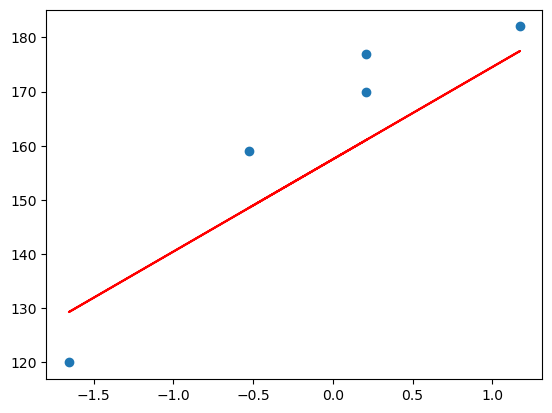

In [147]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test), color='r')

# Performance Metrics-:

In [148]:
# MSE,MAE,RMSE-:
from sklearn.metrics import mean_squared_error,mean_absolute_error,

SyntaxError: trailing comma not allowed without surrounding parentheses (3057349467.py, line 2)

In [ ]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)

In [ ]:
mse,mae,rmse

(109.77592599051654, 9.822657814519227, np.float64(10.477400726827076))

## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)

In [ ]:
score

0.7769869860423441

## Adjusted R Square

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [ ]:
# Display adjusted R-squared-:
1 - ((1- score)*(len(y_test)-1))/(len(y_test)-X_test.shape[1]-1)

0.7026493147231254

In [ ]:
regressor

LinearRegression()

In [ ]:
# New data point-:
sclaed_weight = scaler.transform([[80]])

c:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
sclaed_weight

array([[0.32350772]])

In [ ]:
print(f"Height for 80 kg person-: {regressor.predict(sclaed_weight)}")

Height for 80 kg person-: [[163.01076266]]


# Assumptions-:

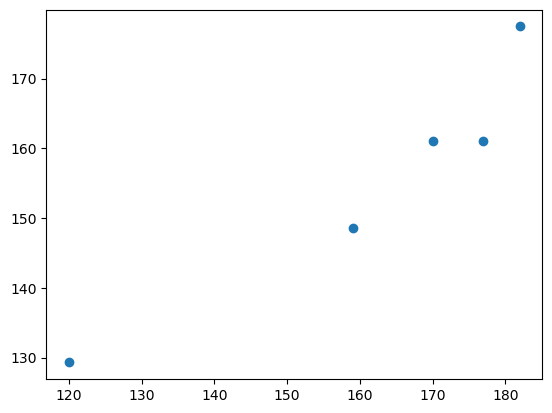

In [ ]:
# plot a scatter plot for the prediction-:
plt.scatter(y_test,y_pred_test)

If the relationship b/w y_test and y_pred_test is LINEAR then regression model is PERFORMING well.

Here; since there is a LINEAR RELATIONSHIP/DISTRIBUTION b/w y_test and y_pred_test.
So; Model is PERFORMING good.

In [ ]:
# Residuals-:
residuals = y_test - y_pred_test

In [ ]:
residuals.reset_index(drop=True,inplace=True)

In [ ]:
residuals

,Height
0,15.915329
1,8.915329
2,-9.304156
3,4.543549
4,10.434926


C:\Users\Omkar Raut\AppData\Local\Temp\ipykernel_26468\3487039179.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: ylabel='Density'>

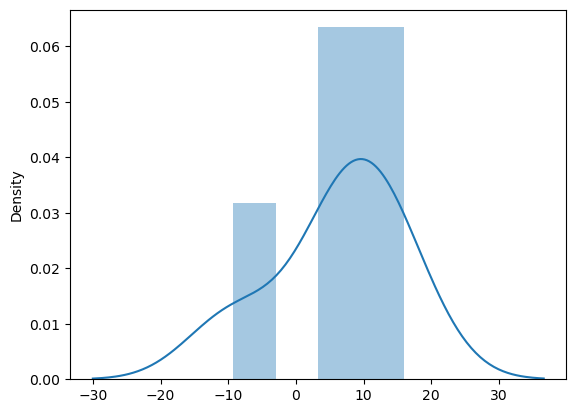

In [152]:
# plot this residuals-:
import seaborn as sns
sns.distplot(residuals,kde=True)

If we plot the residuals and we are getting a normal distribution curve like we are getting here kind of then it is a GOOD MODEL OVERALL.

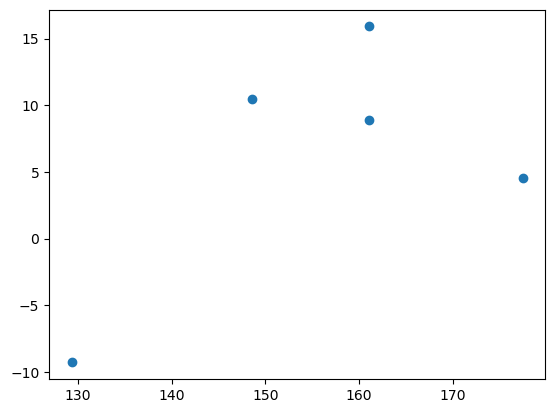

In [153]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)

So; here the scatter plot w.r.t prediction and residuals is UNIFORMLY DISTRIBUTED.
So; The model is good and assumptions are satisfied

In [154]:
# ✅ If residuals are randomly / uniformly scattered →
# The model is good and assumptions are satisfied.

# ❌ If residuals show a clear pattern →
# The model is badly fitted because it is missing patterns in the data.

# Meaning of “missing patterns”:
# The model is too simple and cannot learn the true relationship in the data
# (e.g., real relation is curved but model is a straight line).

# One-line summary:

# Random residuals = good model, patterned residuals = model missing real data patterns.

# So; we should perform these assumptions after training a regression MODEL.